# Day 3 - Exploratory Data Analysis

## Objectives

- NAV trend analysis
- AUM growth analysis
- SIP inflow analysis
- Category inflow analysis
- Investor demographics
- Geographic analysis
- Portfolio allocation analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
aum = pd.read_csv(
    "../Data/Processed/03_aum_by_fund_house.csv"
)

aum.head()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/Processed/03_aum_by_fund_house.csv'

In [3]:
import os

print(os.getcwd())

C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Notebooks


In [4]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Day1_Data_Ingestion.ipynb',
 'Day2_Data_Cleaning.ipynb',
 'EDA_Analysis.ipynb',
 'Mutual_Fund_Capstone_Project.ipynb']

In [5]:
os.listdir("Data")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Data'

In [6]:
import os

os.listdir("..")

['.git',
 'bluestock_mf.db',
 'Dashboard',
 'Data',
 'data_dictionary.md',
 'data_ingestion.py',
 'live_nav_fetch.py',
 'Notebooks',
 'reports',
 'requirements.txt',
 'sql']

In [7]:
os.listdir("../Data")

['Processed', 'Raw']

In [8]:
os.listdir("../Data/Processed")

['clean_aum_by_fund_house.csv',
 'clean_benchmark_indices.csv',
 'clean_category_inflows.csv',
 'clean_fund_master.csv',
 'clean_industry_folio_count.csv',
 'clean_investor_transactions.csv',
 'clean_monthly_sip_inflows.csv',
 'clean_nav_history.csv',
 'clean_portfolio_holdings.csv',
 'clean_scheme_performance.csv']

In [10]:
pd.read_csv("../Data/Processed/clean_aum_by_fund_house.csv")

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
...,...,...,...,...,...
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
88,2025-12-31,Mirae Asset MF,2.90,290000,56


In [11]:
fund_master = pd.read_csv(
    "../Data/Processed/clean_fund_master.csv"
)

In [12]:
nav = pd.read_csv(
    "../Data/Processed/clean_nav_history.csv"
)

In [13]:
aum = pd.read_csv(
    "../Data/Processed/clean_aum_by_fund_house.csv"
)

In [14]:
sip = pd.read_csv(
    "../Data/Processed/clean_monthly_sip_inflows.csv"
)

In [15]:
transactions = pd.read_csv(
    "../Data/Processed/clean_investor_transactions.csv"
)

In [16]:
performance = pd.read_csv(
    "../Data/Processed/clean_scheme_performance.csv"
)

In [17]:
holdings = pd.read_csv(
    "../Data/Processed/clean_portfolio_holdings.csv"
)

In [18]:
category = pd.read_csv(
    "../Data/Processed/clean_category_inflows.csv"
)

In [19]:
folios = pd.read_csv(
    "../Data/Processed/clean_industry_folio_count.csv"
)

In [20]:
import pandas as pd

fund_master = pd.read_csv("../Data/Processed/clean_fund_master.csv")
nav = pd.read_csv("../Data/Processed/clean_nav_history.csv")
aum = pd.read_csv("../Data/Processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../Data/Processed/clean_monthly_sip_inflows.csv")
transactions = pd.read_csv("../Data/Processed/clean_investor_transactions.csv")
performance = pd.read_csv("../Data/Processed/clean_scheme_performance.csv")
holdings = pd.read_csv("../Data/Processed/clean_portfolio_holdings.csv")
category = pd.read_csv("../Data/Processed/clean_category_inflows.csv")
folios = pd.read_csv("../Data/Processed/clean_industry_folio_count.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [21]:
fund_master = pd.read_csv("../Data/Processed/clean_fund_master.csv")
nav = pd.read_csv("../Data/Processed/clean_nav_history.csv")
aum = pd.read_csv("../Data/Processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../Data/Processed/clean_monthly_sip_inflows.csv")
transactions = pd.read_csv("../Data/Processed/clean_investor_transactions.csv")
performance = pd.read_csv("../Data/Processed/clean_scheme_performance.csv")
holdings = pd.read_csv("../Data/Processed/clean_portfolio_holdings.csv")
category = pd.read_csv("../Data/Processed/clean_category_inflows.csv")
folios = pd.read_csv("../Data/Processed/clean_industry_folio_count.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


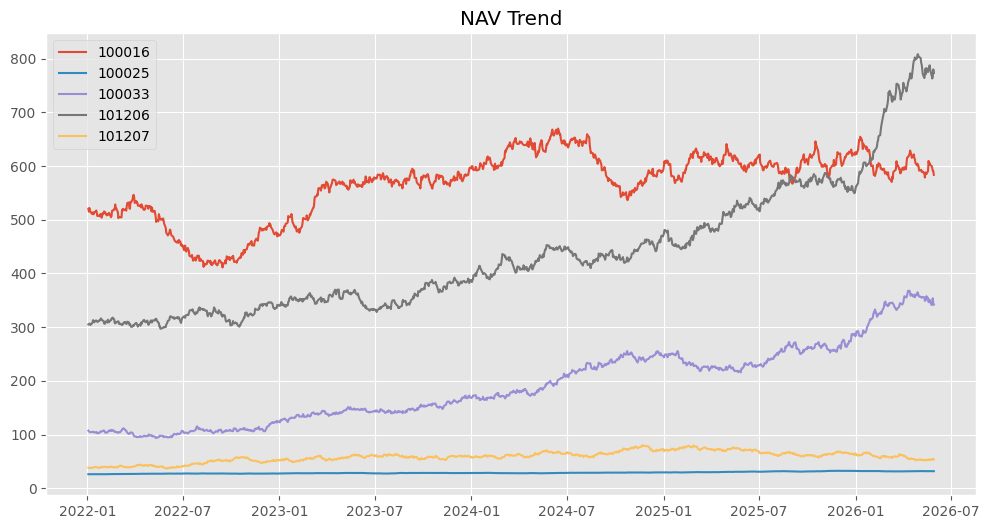

In [22]:
nav["date"] = pd.to_datetime(nav["date"])

sample_codes = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in sample_codes:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=str(code))

plt.title("NAV Trend")
plt.legend()
plt.show()

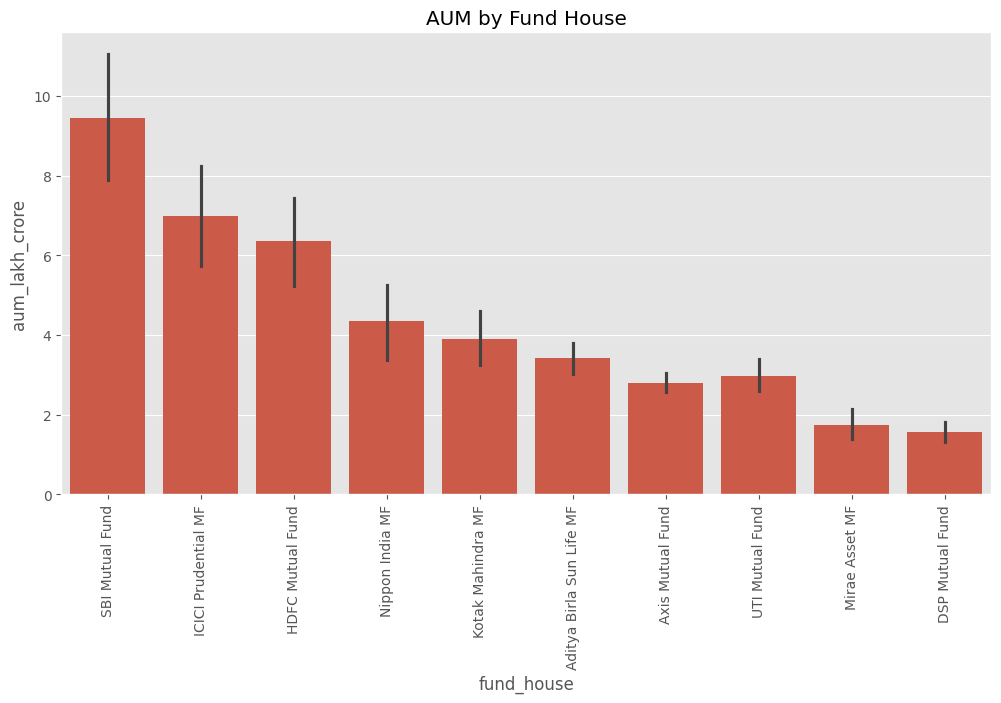

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.show()

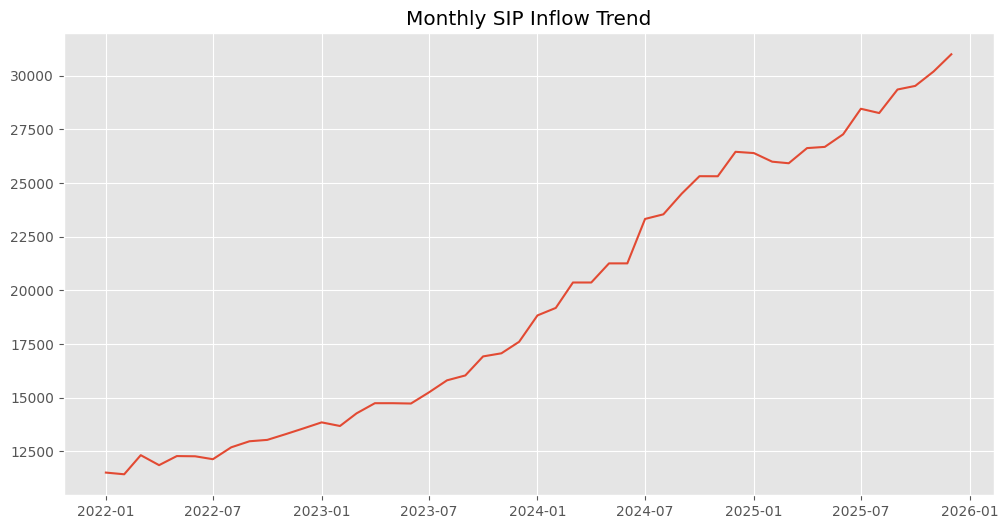

In [24]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.show()

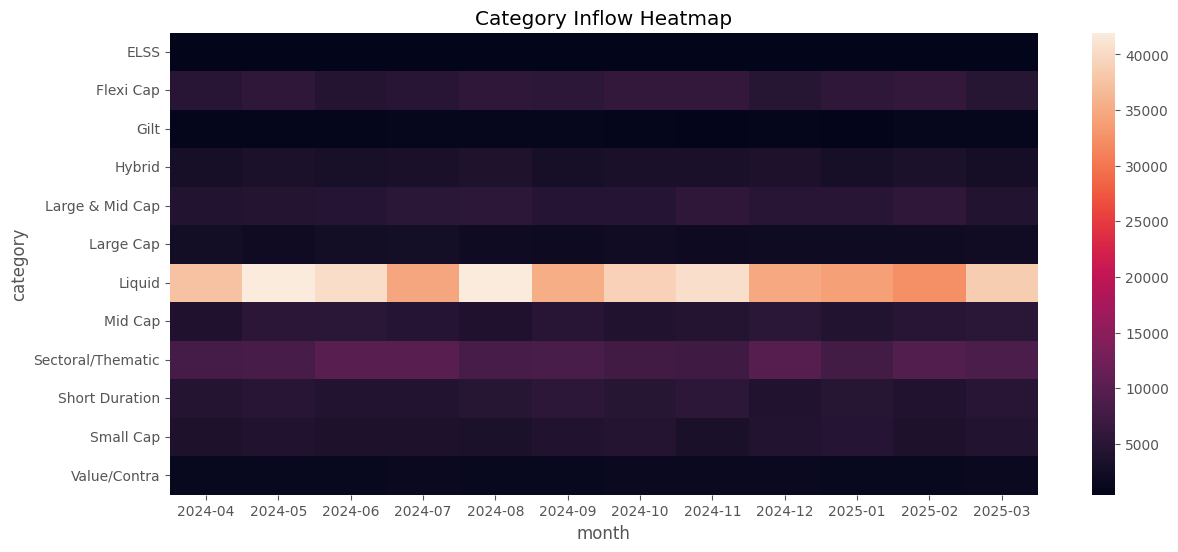

In [25]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")
plt.show()

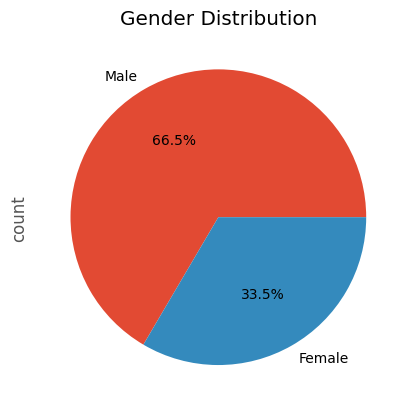

In [26]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

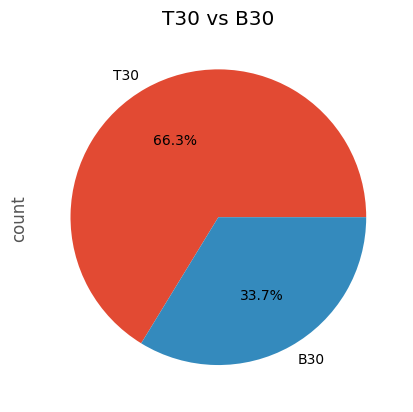

In [27]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")

plt.show()


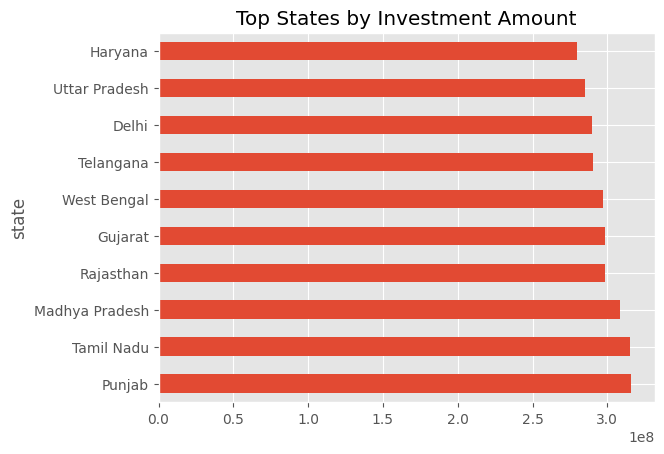

In [28]:
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_data.plot(
    kind="barh"
)

plt.title("Top States by Investment Amount")

plt.show()

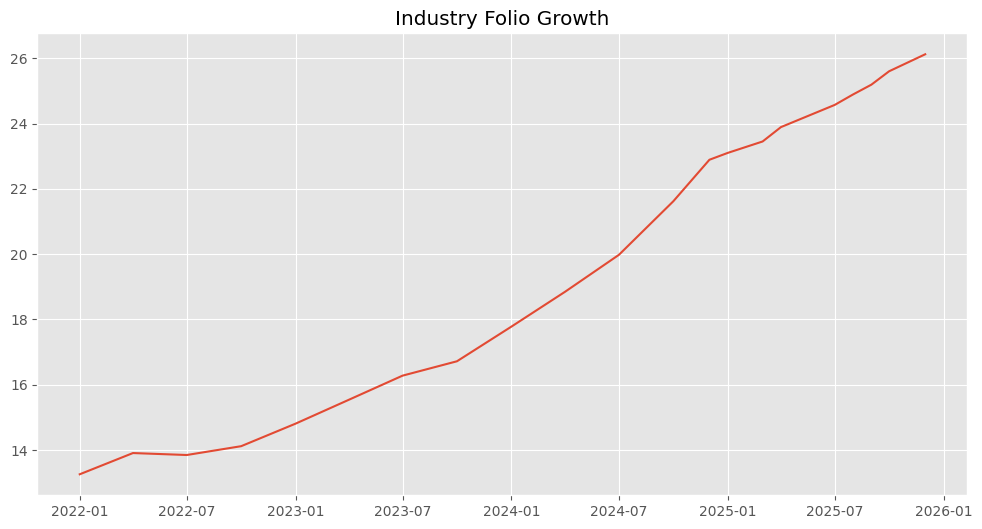

In [29]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.show()

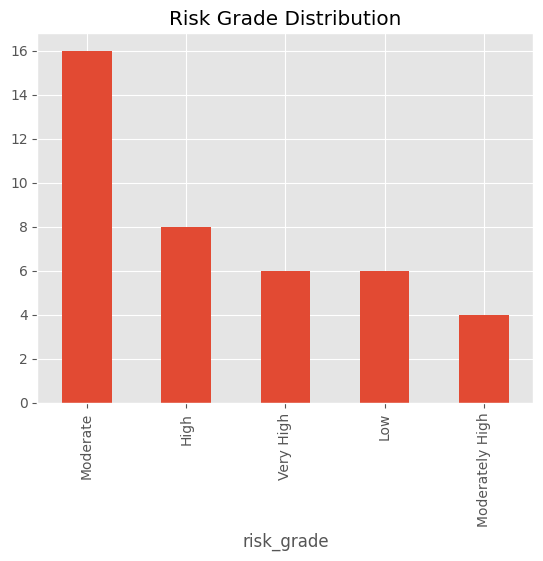

In [30]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Grade Distribution")

plt.show()

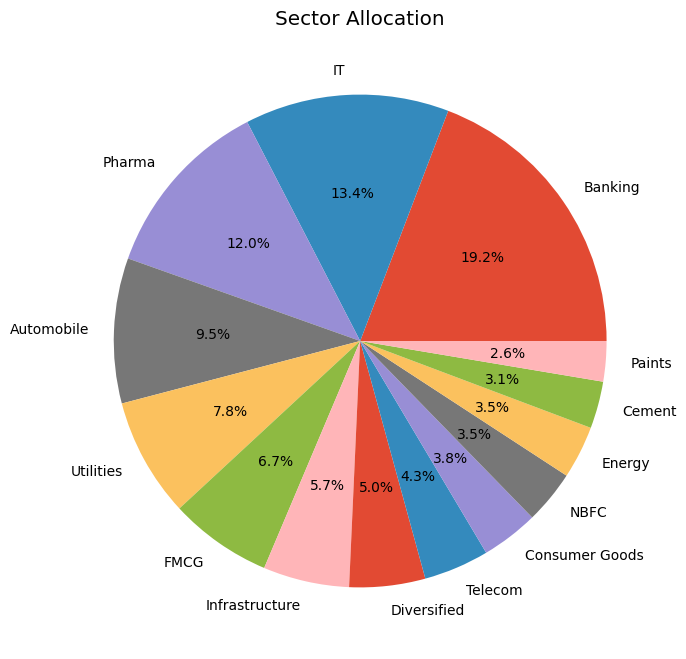

In [31]:
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")

plt.show()

# Key EDA Findings

1. SIP inflows showed consistent growth from 2022–2025.
2. SBI Mutual Fund remained among the largest fund houses by AUM.
3. Folio counts increased significantly over the analysis period.
4. Male investors represented a larger share of transactions.
5. T30 cities contributed the majority of investments.
6. Equity-oriented schemes dominated assets under management.
7. Expense ratios were within industry norms.
8. NAV values displayed long-term upward trends.
9. Sector allocations were concentrated in Financials and Technology.
10. Risk grades were primarily Moderate to High.